In [62]:
import torch
import torch.nn as nn
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from torch.nn import BCELoss, BCEWithLogitsLoss
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
plt.style.use("default")

In [63]:
print(torch.cuda.is_available())

True


In [64]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device = "cpu"

In [65]:
X = np.random.uniform(size=(1000,2))
y = np.logical_xor(np.round(X[:, 0]), np.round(X[:, 1])).astype(int).reshape(-1, 1)

X = torch.from_numpy(X).float().to(device)
y = torch.from_numpy(y).float().to(device)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_test = y_test.cpu()

trainXOR_dataset = TensorDataset(X_train, y_train)
trainXOR_loader = DataLoader(trainXOR_dataset, batch_size=16)

In [66]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.layer1 = nn.Linear(2, 8)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.sigmoid(self.layer2(x))
        return x

In [67]:
def train_new_model(optimizer_name: str, MAX_EPOCHS: int) -> MLP:
    torch.manual_seed(42)
    model = MLP()
    model.to(device)

    loss_fn = BCELoss()

    optimizer = {
        "SGD": torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9),
        "Adam": torch.optim.Adam(model.parameters(), lr=0.01),
    }[optimizer_name]

    print_every = MAX_EPOCHS / 10

    for epoch_index in range(MAX_EPOCHS):
        model.train()

        running_loss = 0.0

        for data, target in trainXOR_loader:
            optimizer.zero_grad()

            y_pred = model(data)

            loss = loss_fn(y_pred, target)
            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        model.eval()

        with torch.no_grad():
            y_pred = model(X_test)
            y_pred = np.round(y_pred.detach().cpu().numpy())
            accuracy = accuracy_score(y_test, y_pred)

        avg_loss = running_loss / len(trainXOR_loader)
        last_loss = avg_loss

        if epoch_index % print_every == print_every-1:
            print(f"{epoch_index=} {last_loss=} {accuracy=}")

    return model


In [68]:
def print_draw_test_accuracy(model):
    y_pred = model(X_test)
    y_pred = np.round(y_pred.detach().cpu().numpy())
    print(f"accuracy={accuracy_score(y_test, y_pred):.3f}")

    plt.scatter(X_test.cpu()[:, 0], X_test.cpu()[:, 1], c=y_pred)
    plt.axhline(y=0.5)
    plt.axvline(x=0.5)
    plt.show()


epoch_index=9 last_loss=0.24084998786449432 accuracy=0.915
epoch_index=19 last_loss=0.10553462322801352 accuracy=0.955
epoch_index=29 last_loss=0.0787101894337684 accuracy=0.97
epoch_index=39 last_loss=0.06632925571640953 accuracy=0.97
epoch_index=49 last_loss=0.057833859121601564 accuracy=0.97
epoch_index=59 last_loss=0.051253506147913866 accuracy=0.97
epoch_index=69 last_loss=0.04761840945458971 accuracy=0.97
epoch_index=79 last_loss=0.043807648963847895 accuracy=0.975
epoch_index=89 last_loss=0.041059135186169445 accuracy=0.975
epoch_index=99 last_loss=0.03888092181581669 accuracy=0.975
accuracy=0.975


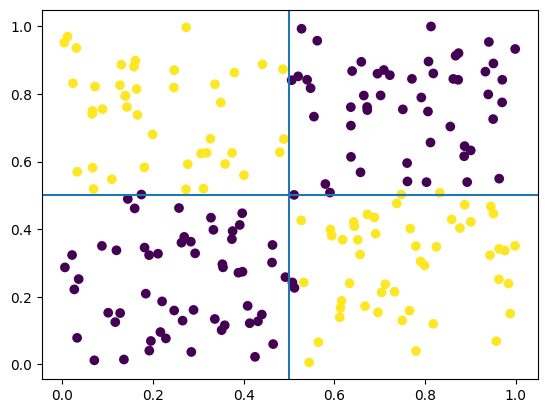

In [69]:
model_sgd = train_new_model("SGD", 100)
print_draw_test_accuracy(model_sgd)

epoch_index=19 last_loss=0.22723124131560327 accuracy=0.92
epoch_index=39 last_loss=0.12163519471883774 accuracy=0.975
epoch_index=59 last_loss=0.08401525475084781 accuracy=0.985
epoch_index=79 last_loss=0.0677367735048756 accuracy=0.98
epoch_index=99 last_loss=0.05800967823481187 accuracy=0.98
epoch_index=119 last_loss=0.05156312793726101 accuracy=0.98
epoch_index=139 last_loss=0.046721772495657204 accuracy=0.98
epoch_index=159 last_loss=0.04319299939728807 accuracy=0.985
epoch_index=179 last_loss=0.040339980316348376 accuracy=0.985
epoch_index=199 last_loss=0.03761538910388481 accuracy=0.985
accuracy=0.985


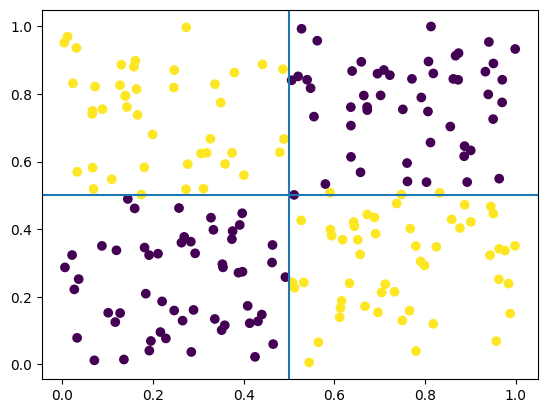

In [70]:
model_adam = train_new_model("Adam", 200)
print_draw_test_accuracy(model_adam)